### Import Modules, then Load & Clean Data, then Create Subsets of Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, 
    root_mean_squared_error, 
    classification_report, 
    accuracy_score, 
    ConfusionMatrixDisplay
)

# Load data
df = pd.read_csv('StudentPerformanceFactors.csv')

# Drop rows where target is missing
df = df.dropna()

---

### Logistic Regression to Classify School Type based on Exam Score

Accuracy: 0.5039

Classification Report:
              precision    recall  f1-score   support

     Private       0.32      0.47      0.38       415
      Public       0.67      0.52      0.58       861

    accuracy                           0.50      1276
   macro avg       0.50      0.50      0.48      1276
weighted avg       0.56      0.50      0.52      1276



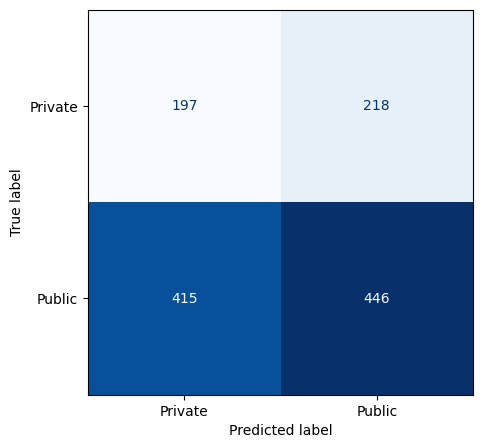

In [2]:
###################################################################################
#
#  Logistic regression model to classify school type based on exam score
#
###################################################################################

# Create data subsets
X = pd.DataFrame(df['Exam_Score'])
y = df['School_Type']

# Create the logistic regression model object
clf_lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
clf_lr.fit(X_train, y_train)

# Evaluate
y_pred_lr = clf_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr)

print(f"Accuracy: {acc_lr:.4f}\n")
print("Classification Report:")
print(report_lr)

# Create confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred_lr, 
        ax=ax, 
        cmap='Blues',
        colorbar=False
    )

Accuracy: 0.4781

Classification Report:
              precision    recall  f1-score   support

     Private       0.31      0.51      0.39       415
      Public       0.66      0.46      0.55       861

    accuracy                           0.48      1276
   macro avg       0.49      0.49      0.47      1276
weighted avg       0.55      0.48      0.49      1276



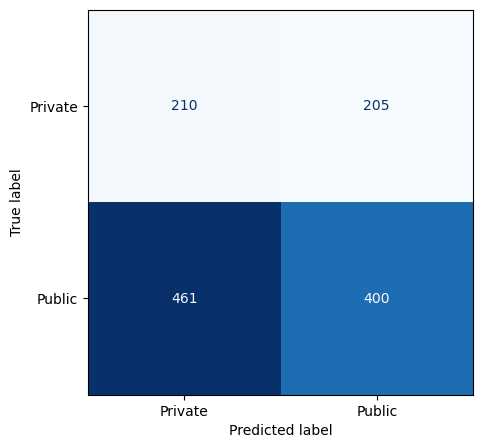

In [3]:
###################################################################################
#
#  Random forest classifier model to predict school type based on exam score
#
###################################################################################

# Create data subsets
clf_rf = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')

# Train the model
clf_rf.fit(X_train, y_train)

# Predict and Evaluate
y_pred = clf_rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(report)

# Create confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        ax=ax, 
        cmap='Blues',
        colorbar=False
    )

---

### Radom Forest Classifier to Classify School Type based on Exam Score

In [4]:
### Create new data subsets for regression

# Load data
X = df.drop(columns=['Exam_Score'])

# Create one-hot-oncoding for qualitative features
X_encoded = pd.get_dummies(X, drop_first=True)
y = df['Exam_Score']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=12)

### Linear Regression using Forwards Feature Selection


Forward Selection
Optimal Number of Features: 24 (Out of 27)
Selected Features: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_Low', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Medium', 'Peer_Influence_Positive', 'Family_Income_Low', 'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Near', 'Motivation_Level_Low', 'Learning_Disabilities_Yes', 'Extracurricular_Activities_Yes', 'Internet_Access_Yes', 'Peer_Influence_Neutral', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Family_Income_Medium', 'Motivation_Level_Medium', 'Physical_Activity', 'Parental_Education_Level_High School', 'Distance_from_Home_Moderate']
Out-of-Sample (Test) R-squared: 0.726
Out-of-Sample (Test) RMSE: 2.073
Top 3 Most Impactful Features (by absolute coefficient): ['Access_to_Resources_Low', 'Parental_Involvement_Low', 'Family_Income_Low']


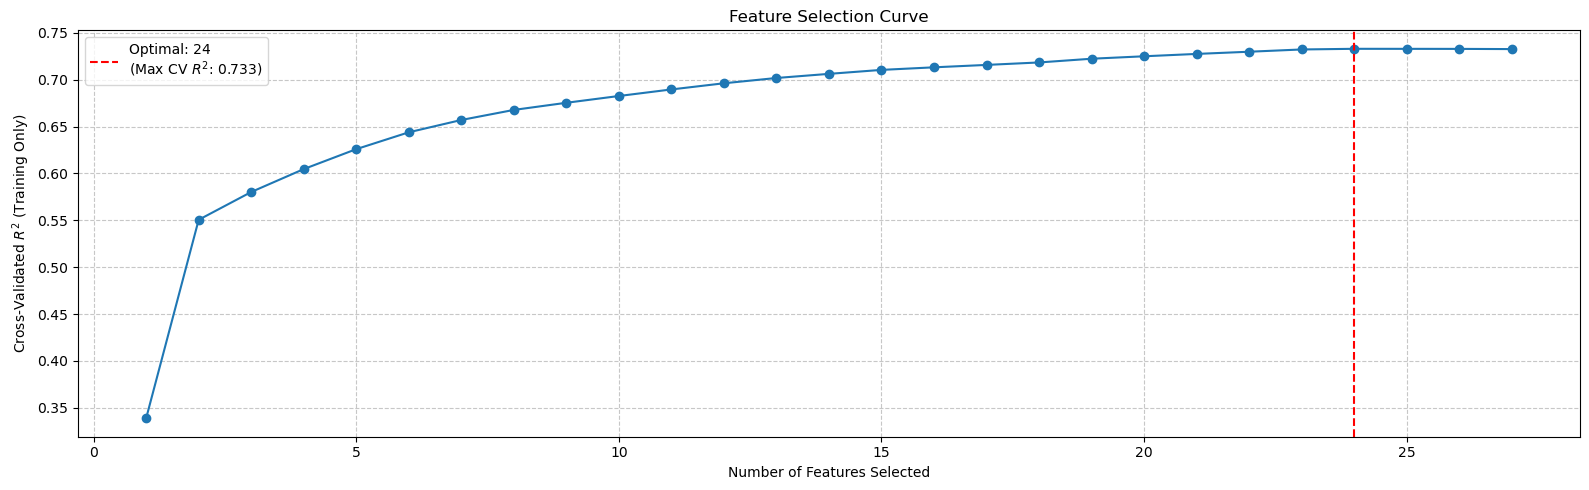

In [5]:
###################################################################################
#
#  Function to perform forward feature selection with linear regression
#
###################################################################################

def plot_and_evaluate_forward_selection(X_train, X_test, y_train, y_test):
    print(f"\n{'='*20}\nForward Selection\n{'='*20}")
    
    total_features = X_train.shape[1]
    selected_features = []
    remaining_features = list(X_train.columns)
    cv_r2_scores = []
    
    lin_reg = LinearRegression()
    
    # Select based purely on Cross-Validated R^2
    for i in range(1, total_features + 1):
        best_cv_r2 = -np.inf
        best_feature = None
        
        for feature in remaining_features:
            test_features = selected_features + [feature]
            # CV evaluated ONLY on training data
            score = cross_val_score(lin_reg, X_train[test_features], y_train, cv=5, scoring='r2').mean()
            
            if score > best_cv_r2:
                best_cv_r2 = score
                best_feature = feature
                
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        cv_r2_scores.append(best_cv_r2)
        
    # Find the peak of the CV curve
    max_cv_r2 = max(cv_r2_scores)
    optimal_num = cv_r2_scores.index(max_cv_r2) + 1
    best_feature_names = selected_features[:optimal_num]
    
    print(f"Optimal Number of Features: {optimal_num} (Out of {total_features})")
    print(f"Selected Features: {best_feature_names}")
    
    # Train final model on optimally selected features
    lin_reg.fit(X_train[best_feature_names], y_train)
    y_pred = lin_reg.predict(X_test[best_feature_names])
    
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"Out-of-Sample (Test) R-squared: {test_r2:.3f}")
    print(f"Out-of-Sample (Test) RMSE: {test_rmse:.3f}")
    
    # --- NEW: Display Top 3 Features ---
    # Handle edge case where optimal features are less than 3
    num_to_display = min(3, len(best_feature_names))
    coef_magnitudes = np.abs(lin_reg.coef_)
    top_indices = np.argsort(coef_magnitudes)[-num_to_display:][::-1]
    top_features = [best_feature_names[i] for i in top_indices]
    print(f"Top {num_to_display} Most Impactful Features (by absolute coefficient): {top_features}")
    
    # Feature Selection Curve Plot
    fig, ax = plt.subplots(figsize=(16, 5))
    
    ax.plot(range(1, total_features + 1), cv_r2_scores, marker='o', linestyle='-')
    ax.set_title(f'Feature Selection Curve')
    ax.set_xlabel('Number of Features Selected')
    ax.set_ylabel('Cross-Validated $R^2$ (Training Only)')
    ax.axvline(x=optimal_num, color='red', linestyle='--', 
                label=f'Optimal: {optimal_num}\n(Max CV $R^2$: {max_cv_r2:.3f})')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
# Execute the regression model
plot_and_evaluate_forward_selection(X_train, X_test, y_train, y_test)

---

### Function for Linear Regression using Backwards Feature Selection


Backward Selection
Optimal Number of Features: 24 (Out of 27)
Selected Features: ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Access_to_Resources_Medium', 'Extracurricular_Activities_Yes', 'Motivation_Level_Low', 'Motivation_Level_Medium', 'Internet_Access_Yes', 'Family_Income_Low', 'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Peer_Influence_Neutral', 'Peer_Influence_Positive', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near']
Out-of-Sample (Test) R-squared: 0.726
Out-of-Sample (Test) RMSE: 2.073
Top 3 Most Impactful Features (by absolute coefficient): ['Access_to_Resources_Low', 'Parental_Involvement_Low', 'Family_Income_Low']


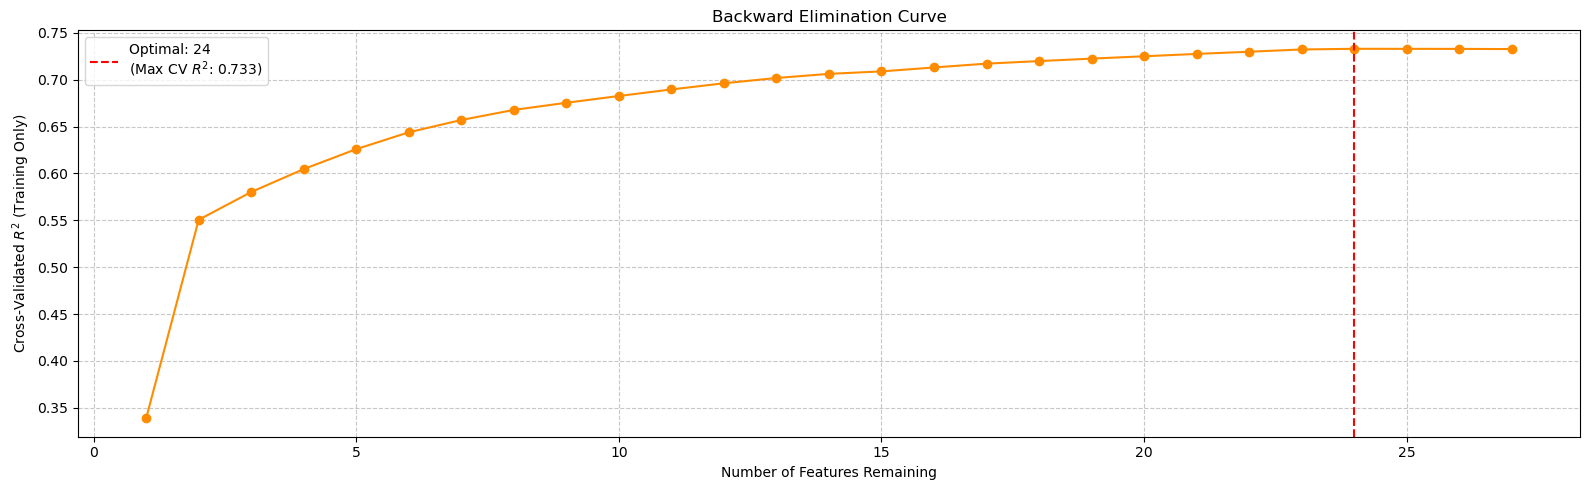

In [6]:
###################################################################################
#
#  Function to perform backward feature selection with linear regression
#
###################################################################################

def plot_and_evaluate_backward_selection(X_train, X_test, y_train, y_test):
    print(f"\n{'='*20}\nBackward Selection\n{'='*20}")
    
    lin_reg = LinearRegression()
    current_features = list(X_train.columns)
    total_features = len(current_features)
    
    # Tracking variables
    cv_r2_scores = []
    feature_sets_history = []
    
    # Evaluate the baseline model with ALL features
    initial_score = cross_val_score(lin_reg, X_train[current_features], y_train, cv=5, scoring='r2').mean()
    cv_r2_scores.append(initial_score)
    feature_sets_history.append(list(current_features))
    
    # Iteratively drop one feature at a time
    for i in range(total_features - 1, 0, -1):
        best_cv_r2 = -np.inf
        feature_to_drop = None
        
        # Test dropping each remaining feature
        for feature in current_features:
            test_features = [f for f in current_features if f != feature]
            score = cross_val_score(lin_reg, X_train[test_features], y_train, cv=5, scoring='r2').mean()
            
            # Find the feature whose removal results in the highest remaining CV score
            if score > best_cv_r2:
                best_cv_r2 = score
                feature_to_drop = feature
                
        # Drop the worst-performing feature from the current pool
        current_features.remove(feature_to_drop)
        cv_r2_scores.append(best_cv_r2)
        feature_sets_history.append(list(current_features))
        
    # Reverse the histories so the x-axis reads from 1 up to total_features (matching the forward selection plot)
    cv_r2_scores.reverse()
    feature_sets_history.reverse()
    
    # Find the peak of the CV curve
    max_cv_r2 = max(cv_r2_scores)
    optimal_index = cv_r2_scores.index(max_cv_r2)
    optimal_num = optimal_index + 1
    best_feature_names = feature_sets_history[optimal_index]
    
    print(f"Optimal Number of Features: {optimal_num} (Out of {total_features})")
    print(f"Selected Features: {best_feature_names}")
    
    # Train final model on optimally selected features
    lin_reg.fit(X_train[best_feature_names], y_train)
    y_pred = lin_reg.predict(X_test[best_feature_names])
    
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"Out-of-Sample (Test) R-squared: {test_r2:.3f}")
    print(f"Out-of-Sample (Test) RMSE: {test_rmse:.3f}")
    
    # Display Top 3 Features
    num_to_display = min(3, len(best_feature_names))
    coef_magnitudes = np.abs(lin_reg.coef_)
    top_indices = np.argsort(coef_magnitudes)[-num_to_display:][::-1]
    top_features = [best_feature_names[i] for i in top_indices]
    print(f"Top {num_to_display} Most Impactful Features (by absolute coefficient): {top_features}")
    
    # Feature Selection Curve Plot
    fig, ax= plt.subplots(figsize=(16, 5))
    
    ax.plot(range(1, total_features + 1), cv_r2_scores, marker='o', linestyle='-', color='darkorange')
    ax.set_title(f'Backward Elimination Curve')
    ax.set_xlabel('Number of Features Remaining')
    ax.set_ylabel('Cross-Validated $R^2$ (Training Only)')
    ax.axvline(x=optimal_num, color='red', linestyle='--', 
                label=f'Optimal: {optimal_num}\n(Max CV $R^2$: {max_cv_r2:.3f})')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_and_evaluate_backward_selection(X_train, X_test, y_train, y_test)

---

### Function for Pruned Random Forest Regressor using Train-Test Split

In [7]:
###################################################################################
#
#  Function for Pruned Random Forest Regressor using Train-Test Split
#
###################################################################################

def evaluate_pruned_random_forest(X_train, X_test, y_train, y_test):
    print(f"\n{'='*25}\nRandom Forest Pruning\n{'='*25}")
    
    rf = RandomForestRegressor(random_state=12, n_jobs=-1)
    
    # Grid Search for optimal complexity penalty (ccp_alpha)
    param_grid = {'ccp_alpha': np.linspace(0, 0.05, 10)}
    grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    
    print("Running Grid Search...")
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    
    print(f"Best ccp_alpha: {grid_search.best_params_['ccp_alpha']:.4f}")
    
    # Evaluate final model on the independent test set
    y_pred = best_rf.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"Test Set R-squared: {test_r2:.3f}")
    print(f"Test Set RMSE: {test_rmse:.3f}")
    
    # Display Top 3 Features
    num_to_display = min(3, len(X_train.columns))
    importances = best_rf.feature_importances_
    top_indices = np.argsort(importances)[-num_to_display:][::-1]
    top_features = [X_train.columns[i] for i in top_indices]
    print(f"Top {num_to_display} Most Impactful Features (by RF Importance): {top_features}")

evaluate_pruned_random_forest(X_train, X_test, y_train, y_test)


Random Forest Pruning
Running Grid Search...
Best ccp_alpha: 0.0000
Test Set R-squared: 0.619
Test Set RMSE: 2.442
Top 3 Most Impactful Features (by RF Importance): ['Attendance', 'Hours_Studied', 'Previous_Scores']


---

### Function for Random Forest Regressor using 5-Fold CV

In [8]:
def evaluate_unpruned_random_forest(X, y):
    print(f"\n{'='*35}\nUnpruned Random Forest 5-Fold CV\n{'='*35}")
    
    # Create the random forest regressor object
    tree_reg_model = RandomForestRegressor(random_state=12, n_jobs=-1)
    
    # Use k-fold cross validation to calculate R^2 and RMSE scores of different subsets
    cv_r2_scores = cross_val_score(tree_reg_model, X, y, cv=5, scoring='r2')
    cv_neg_mse_scores = cross_val_score(tree_reg_model, X, y, cv=5, scoring='neg_mean_squared_error')
    cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)
    
    # Print results
    print(f"Individual R-squared scores: {cv_r2_scores.round(3)}")
    print(f"Average R-squared: {round(cv_r2_scores.mean(),3)} (Standard Deviation: +/- {round(cv_r2_scores.std(),3)})")
    print(f"Individual RMSE scores: {cv_rmse_scores.round(3)}")
    print(f"Average RMSE: {round(cv_rmse_scores.mean(),3)} (Standard Deviation: +/- {round(cv_rmse_scores.std(),3)})")

    # Display Top 3 Features
    # We must fit the model once on the full passed-in X, y to extract feature importances
    tree_reg_model.fit(X, y)
    num_to_display = min(3, len(X.columns))
    importances = tree_reg_model.feature_importances_
    top_indices = np.argsort(importances)[-num_to_display:][::-1]
    top_features = [X.columns[i] for i in top_indices]
    print(f"Top {num_to_display} Most Impactful Features (by RF Importance): {top_features}")

evaluate_unpruned_random_forest(X_encoded, y)


Unpruned Random Forest 5-Fold CV
Individual R-squared scores: [0.532 0.611 0.602 0.636 0.693]
Average R-squared: 0.615 (Standard Deviation: +/- 0.052)
Individual RMSE scores: [2.709 2.443 2.445 2.348 2.106]
Average RMSE: 2.41 (Standard Deviation: +/- 0.194)
Top 3 Most Impactful Features (by RF Importance): ['Attendance', 'Hours_Studied', 'Previous_Scores']


---